In [82]:
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import numpy as np

In [83]:
Slog = []
with open("Slog.txt", 'r') as SlogF:
    fk = 16
    log = []
    for line in SlogF.readlines():
        line = line.strip().split(' ')
        k, *v = int(line[0]), float(line[1]), float(line[2])
        if k == fk:
            log.append(v)
        else:
            Slog.append(np.array(log).transpose())
            log = [v]
            fk = k
    Slog.append(np.array(log).transpose())

In [84]:
Contour = []
with open("Contour.txt", 'r') as ContourF:
    arr = []
    for line in ContourF.readlines():
        line = line.strip()
        if line == "":
            Contour.append(np.array(arr).transpose())
            arr = []
            continue
        arr.append(list(map(np.double, line.split(" "))))

In [85]:
print(Contour[4].shape)

(129, 129)


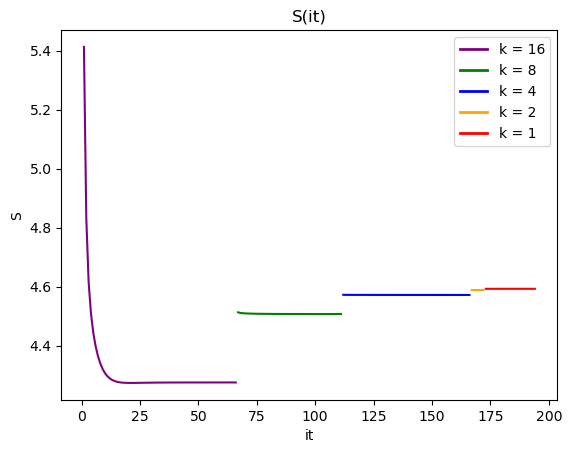

In [86]:
plotsColors = ('purple', 'green', 'blue', 'orange', 'red')
legend_handles = (
    Line2D([0], [0], color = plotsColors[0], lw=2, label = 'k = 16'),
    Line2D([0], [0], color = plotsColors[1], lw=2, label = 'k = 8'),
    Line2D([0], [0], color = plotsColors[2], lw=2, label = 'k = 4'),
    Line2D([0], [0], color = plotsColors[3], lw=2, label = 'k = 2'),
    Line2D([0], [0], color = plotsColors[4], lw=2, label = 'k = 1')
)
plt.xlabel('it')
plt.ylabel('S')
plt.title('S(it)')
plt.legend(loc='upper right', handles = legend_handles)

for data, colors in zip(Slog, plotsColors):
    plt.plot(data[0], data[1], color=colors)

plt.show()

In [87]:
cxs = []
cys = []

for arr in Contour:
    cxs.append(np.linspace(0, arr.shape[0], arr.shape[0]))
    cys.append(np.linspace(0, arr.shape[1], arr.shape[1]))

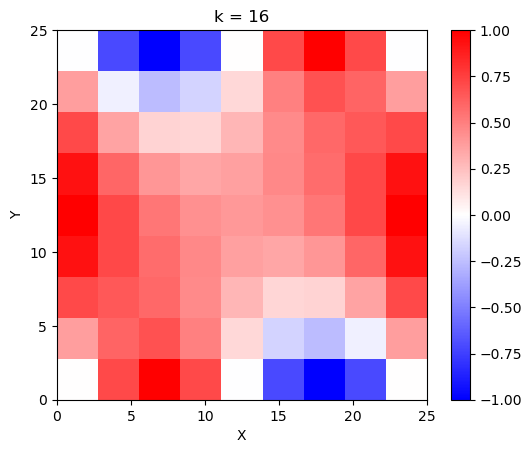

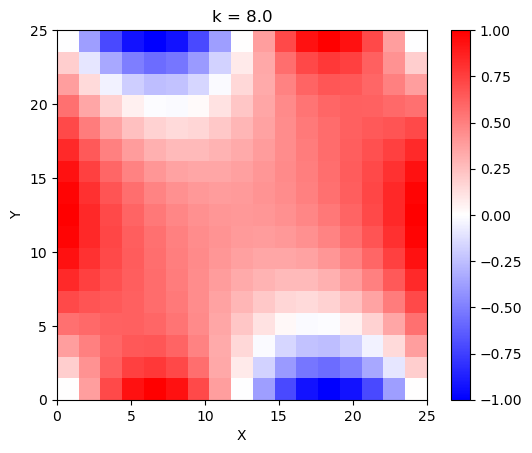

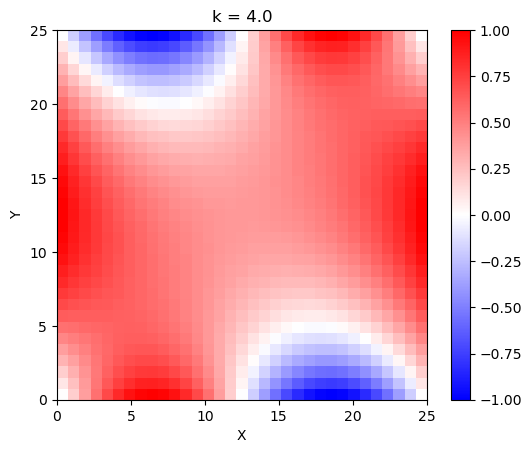

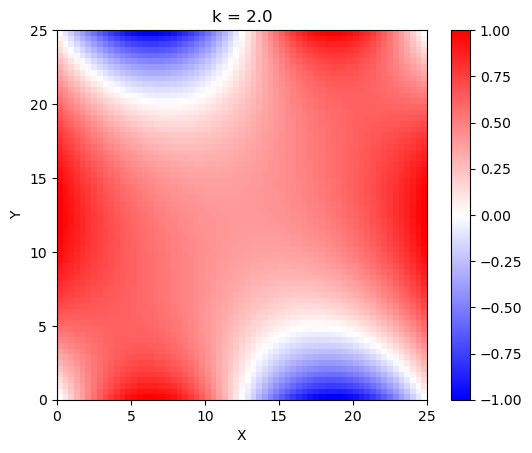

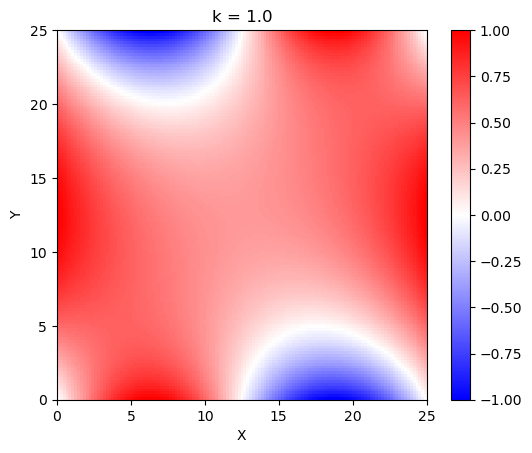

In [89]:
k = 16
for contour in Contour:
    plt.imshow(contour, interpolation='none', origin='lower', cmap="bwr", extent=[0, 25, 0, 25])
    plt.title(f"k = {k}")
    plt.colorbar()
    plt.xlabel('X')
    plt.ylabel('Y')
    plt.savefig(f"k{k}")
    plt.show()
    k //= 2